# Multi-Objective Optimization for Credit Risk: Pareto Front Analysis

## Loan Default Prediction using NSGA-II

**Objective:** Optimize a loan approval system across 3 conflicting objectives:
1. **Maximize Profit** (f1 = -profit)
2. **Maximize Predictive Performance** (f2 = -AUC-ROC)
3. **Maximize Fairness** (f3 = -fairness_score)

**Decision Variables:** Model type, threshold, regularization, class weights, max_depth

**Optimization Algorithm:** NSGA-II (Population=30, Generations=15)

---

In [4]:
import numpy as np
import pandas as pd
import time

# Sklearn
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier


from pymoo.core.problem import Problem
from pymoo.algorithms.moo.nsga2 import NSGA2
from pymoo.operators.sampling.rnd import FloatRandomSampling
from pymoo.operators.crossover.sbx import SBX
from pymoo.operators.mutation.pm import PM
from pymoo.optimize import minimize

# Pipeline + preprocessing
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from pymoo.indicators.hv import HV

In [5]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier


def get_model(model_type, max_depth=None):
    if model_type == "logistic":
        return Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            ("clf", LogisticRegression(max_iter=1000))
        ])
    else:
        return Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("clf", RandomForestClassifier(max_depth=max_depth))
        ])


## Exploring the  Loan Default Dataset

In [6]:
# Load the dataset
data_path = '/Users/ayusharyakashyap/Desktop/IIITB/Semester 8/MOML/project_1/Loan_Default.csv'
df = pd.read_csv(data_path)

print("="*80)
print("DATASET OVERVIEW")
print("="*80)
print(f"\nDataset Shape: {df.shape}")
print(f"Number of Features: {df.shape[1]}")
print(f"Number of Samples: {df.shape[0]}")

print("\n" + "="*80)
print("FIRST FEW ROWS")
print("="*80)
print(df.head(10))

print("\n" + "="*80)
print("TARGET VARIABLE (Status) DISTRIBUTION")
print("="*80)
print(f"Status Value Counts:\n{df['Status'].value_counts()}")
print(f"\nStatus Distribution (%):\n{df['Status'].value_counts(normalize=True) * 100}")

# Verify Status encoding: 1=Default, 0=Non-Default
print(f"\n✓ Target variable convention: Status=1 → Default, Status=0 → Non-Default")

print("\n" + "="*80)
print("DATA TYPES AND MISSING VALUES")
print("="*80)
missing_info = pd.DataFrame({
    'Column': df.columns,
    'Data_Type': df.dtypes.values,
    'Missing_Count': df.isnull().sum().values,
    'Missing_Percent': (df.isnull().sum().values / len(df) * 100).round(2)
})
print(missing_info.to_string(index=False))

print("\n" + "="*80)
print("BASIC STATISTICS")
print("="*80)
print(df.describe())

DATASET OVERVIEW

Dataset Shape: (148670, 34)
Number of Features: 34
Number of Samples: 148670

FIRST FEW ROWS
      ID  year loan_limit             Gender approv_in_adv loan_type  \
0  24890  2019         cf  Sex Not Available         nopre     type1   
1  24891  2019         cf               Male         nopre     type2   
2  24892  2019         cf               Male           pre     type1   
3  24893  2019         cf               Male         nopre     type1   
4  24894  2019         cf              Joint           pre     type1   
5  24895  2019         cf              Joint           pre     type1   
6  24896  2019         cf              Joint           pre     type1   
7  24897  2019        NaN             Female         nopre     type1   
8  24898  2019         cf              Joint         nopre     type1   
9  24899  2019         cf  Sex Not Available         nopre     type3   

  loan_purpose Credit_Worthiness open_credit business_or_commercial  ...  \
0           p1      

In [7]:

print("DATASET OVERVIEW")
print(f"\nDataset Shape: {df.shape}")
print(f"Number of Features: {df.shape[1]}")
print(f"Number of Samples: {df.shape[0]}")



print("="*80)
print(df.head(10))

print("\n" + "="*80)
print("TARGET VARIABLE (Status) DISTRIBUTION")
print("="*80)
print(f"Status Value Counts:\n{df['Status'].value_counts()}")
print(f"\nStatus Distribution (%):\n{df['Status'].value_counts(normalize=True) * 100}")

# Verify Status encoding: 1=Default, 0=Non-Default
print(f"\n✓ Target variable convention: Status=1 → Default, Status=0 → Non-Default")

print("\n" + "="*80)
print("DATA TYPES AND MISSING VALUES")
print("="*80)
missing_info = pd.DataFrame({
    'Column': df.columns,
    'Data_Type': df.dtypes.values,
    'Missing_Count': df.isnull().sum().values,
    'Missing_Percent': (df.isnull().sum().values / len(df) * 100).round(2)
})
print(missing_info.to_string(index=False))

print("\n" + "="*80)
print("BASIC STATISTICS")
print("="*80)
print(df.describe())

DATASET OVERVIEW

Dataset Shape: (148670, 34)
Number of Features: 34
Number of Samples: 148670
      ID  year loan_limit             Gender approv_in_adv loan_type  \
0  24890  2019         cf  Sex Not Available         nopre     type1   
1  24891  2019         cf               Male         nopre     type2   
2  24892  2019         cf               Male           pre     type1   
3  24893  2019         cf               Male         nopre     type1   
4  24894  2019         cf              Joint           pre     type1   
5  24895  2019         cf              Joint           pre     type1   
6  24896  2019         cf              Joint           pre     type1   
7  24897  2019        NaN             Female         nopre     type1   
8  24898  2019         cf              Joint         nopre     type1   
9  24899  2019         cf  Sex Not Available         nopre     type3   

  loan_purpose Credit_Worthiness open_credit business_or_commercial  ...  \
0           p1                l1    

## Data Preprocessing and Feature Engineering

In [8]:
df_processed = df.copy()

In [9]:
#  Drop ID column
print("\n[1] Dropping ID column")
df_processed = df_processed.drop('ID', axis=1)
print(f"    ✓ Dropped ID column. Shape: {df_processed.shape}")

#  Extract and parse AGE into protected groups
print("\n[2] Parsing AGE ranges and creating protected groups...")
def parse_age_group(age_str):
    """Parse age string range into Group A (≤44) or Group B (>44)"""
    if pd.isna(age_str):
        return np.nan
    
    age_str = str(age_str).strip()
    
    # Map age ranges to numeric bounds
    age_mapping = {
        '25-34': (25, 34),
        '35-44': (35, 44),
        '45-54': (45, 54),
        '55-64': (55, 64),
        '65-74': (65, 74),
        '>74': (75, 100),
        '<25': (0, 24)
    }
    
    if age_str in age_mapping:
        lower, upper = age_mapping[age_str]
        midpoint = (lower + upper) / 2
        # Group A: ≤44, Group B: >44
        return 0 if midpoint <= 44 else 1
    
    return np.nan


[1] Dropping ID column
    ✓ Dropped ID column. Shape: (148670, 33)

[2] Parsing AGE ranges and creating protected groups...


In [10]:

df_processed['age_group'] = df_processed['age'].apply(parse_age_group)
print(f" Age Group Distribution:")
print(df_processed['age_group'].value_counts())
print(f" Group A (≤44): {(df_processed['age_group']==0).sum()} samples")
print(f" Group B (>44): {(df_processed['age_group']==1).sum()} samples")

#  Handle missing values
print("\n[3] Handling missing values...")
# For numeric columns: fill with median
numeric_cols = df_processed.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols.remove('Status')  # Don't impute target

for col in numeric_cols:
    missing_count = df_processed[col].isnull().sum()
    if missing_count > 0:
        median_val = df_processed[col].median()
        df_processed[col].fillna(median_val, inplace=True)

# For categorical columns: fill with mode
categorical_cols = df_processed.select_dtypes(include=['object']).columns.tolist()
if 'age' in categorical_cols:
    categorical_cols.remove('age')  

for col in categorical_cols:
    missing_count = df_processed[col].isnull().sum()
    if missing_count > 0:
        mode_val = df_processed[col].mode()[0] if len(df_processed[col].mode()) > 0 else 'Unknown'
        df_processed[col].fillna(mode_val, inplace=True)

# Drop age column as we've extracted age_group
df_processed = df_processed.drop('age', axis=1)

print(f"Filled missing values")
print(f"Remaining missing values: {df_processed.isnull().sum().sum()}")

 Age Group Distribution:
age_group
1.0    95173
0.0    53297
Name: count, dtype: int64
 Group A (≤44): 53297 samples
 Group B (>44): 95173 samples

[3] Handling missing values...
Filled missing values


/var/folders/nt/xg5gfpkj58vgy8hqhlsslg_m0000gn/T/ipykernel_48223/1692858767.py:17: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df_processed[col].fillna(median_val, inplace=True)
/var/folders/nt/xg5gfpkj58vgy8hqhlsslg_m0000gn/T/ipykernel_48223/1692858767.py:17: ChainedAssignmentError: A value is being set on a copy of a DataFrame or

Remaining missing values: 181135


In [11]:
#  Separate target variable
print("\n[4] Extracting target variable...")
y = df_processed['Status'].values
X = df_processed.drop('Status', axis=1)
print(f"Target (y) shape: {y.shape}")
print(f"Features (X) shape: {X.shape}")
print(f"Class distribution - Default (1): {(y==1).sum()}, Non-Default (0): {(y==0).sum()}")

#  One-hot encode categorical variables
print("\n[5] One-hot encoding categorical variables...")
X_encoded = pd.get_dummies(X, columns=categorical_cols, drop_first=True, sparse=False)
print(f" Features after encoding: {X_encoded.shape[1]}")

# Standardize numeric features
print("\n[6] Standardizing numeric features...")
scaler = StandardScaler()
numeric_feature_cols = X_encoded.select_dtypes(include=[np.number]).columns.tolist()
X_scaled = X_encoded.copy()
X_scaled[numeric_feature_cols] = scaler.fit_transform(X_encoded[numeric_feature_cols])

print(f"Scaled {len(numeric_feature_cols)} numeric features")


[4] Extracting target variable...
Target (y) shape: (148670,)
Features (X) shape: (148670, 32)
Class distribution - Default (1): 36639, Non-Default (0): 112031

[5] One-hot encoding categorical variables...
 Features after encoding: 44

[6] Standardizing numeric features...
Scaled 12 numeric features


In [12]:
# Extract protected attribute (age_group)
protected_attr = X_encoded['age_group'].values
X_final = X_scaled.drop('age_group', axis=1)


print(f"PREPROCESSING COMPLETE")
print(f"Final Features (X): {X_final.shape}")
print(f"Target (y): {y.shape}")
print(f"Protected Attribute (age_group): {protected_attr.shape}")


PREPROCESSING COMPLETE
Final Features (X): (148670, 43)
Target (y): (148670,)
Protected Attribute (age_group): (148670,)


## Defining Fairness Metrics and Protected Attributes

In [13]:
def compute_fairness_score(y_pred_prob, decisions, protected_attr, threshold=0.5):
    """
    Compute fairness score based on Demographic Parity.
    
    Demographic Parity: P(approval|Group A) ≈ P(approval|Group B)
    Score ranges from 0 to 1 (higher is fairer)
    
    Args:
        y_pred_prob: Predicted probability of default (shape: n_samples)
        decisions: Binary decisions (approved=1 if prob < threshold, else 0)
        protected_attr: Protected attribute values (0=Group A, 1=Group B)
        threshold: Used to convert probabilities to decisions
    
    Returns:
        fairness_score: Demographic parity score (0-1)
    """
    
    # Approval rate for each group (approval = predicted prob < threshold)
    group_a_mask = (protected_attr == 0)
    group_b_mask = (protected_attr == 1)
    
    # Handle edge cases
    if group_a_mask.sum() == 0 or group_b_mask.sum() == 0:
        return 0.5  # Neutral score if one group is absent
    
    approval_rate_a = decisions[group_a_mask].mean()
    approval_rate_b = decisions[group_b_mask].mean()
    
    # Demographic parity difference (0 = perfect fairness)
    dp_diff = abs(approval_rate_a - approval_rate_b)
    
    # Convert to score (1 = perfectly fair, 0 = maximally unfair)
    fairness_score = 1.0 - min(dp_diff, 1.0)  # Clamp to [0, 1]
    
    return fairness_score, approval_rate_a, approval_rate_b, dp_diff

def apply_fairness_penalty(fairness_score, approval_rate):
    """
    Apply penalty if approval_rate < 5% (trivial fairness via rejection).
    
    This prevents the algorithm from achieving fairness by rejecting all loans.
    
    Args:
        fairness_score: Original fairness score
        approval_rate: Overall approval rate
    
    Returns:
        penalized_fairness_score
    """
    if approval_rate < 0.05:  # Less than 5% approval rate
        penalty = (0.05 - approval_rate) / 0.05  # Penalty up to 1.0
        penalized_score = fairness_score * (1.0 - penalty)
        return penalized_score
    
    return fairness_score


print("FAIRNESS METRICS DEFINED")

print("\n[Fairness Metric] Demographic Parity")
print("  - Measures: |P(approval|Age≤44) - P(approval|Age>44)|")
print("  - Score: 1.0 = perfect fairness, 0.0 = maximum disparity")
print("\n[Fairness Penalty]")
print("  - Penalizes approval_rate < 5% to prevent trivial fairness")
print("  - Ensures meaningful approval rates across all solutions")
print("\n✓ Fairness functions ready for MOO")


FAIRNESS METRICS DEFINED

[Fairness Metric] Demographic Parity
  - Measures: |P(approval|Age≤44) - P(approval|Age>44)|
  - Score: 1.0 = perfect fairness, 0.0 = maximum disparity

[Fairness Penalty]
  - Penalizes approval_rate < 5% to prevent trivial fairness
  - Ensures meaningful approval rates across all solutions

✓ Fairness functions ready for MOO


## Implementing Profit Function

In [14]:
def compute_profit(y_true, y_pred_prob, threshold):
    """
    Compute total profit based on loan decisions.
    
    Profit Logic:
    - Approved & Non-Default (y=0, pred<threshold): +0.1 (profit)
    - Approved & Default (y=1, pred<threshold): -1.0 (loss)
    - Rejected (pred≥threshold): 0 (no transaction)
    
    Args:
        y_true: True labels (1=default, 0=non-default)
        y_pred_prob: Predicted probability of default
        threshold: Probability threshold for approval decision
    
    Returns:
        total_profit: Sum of all transaction profits
        approval_rate: Fraction of loans approved
    """
    
    # Decision: approve if predicted probability < threshold
    decisions = (y_pred_prob < threshold).astype(int)
    
    # Profit computation
    profits = np.zeros(len(y_true))
    
    # Approved non-default loans
    approved_non_default = (decisions == 1) & (y_true == 0)
    profits[approved_non_default] = 0.1
    
    # Approved default loans
    approved_default = (decisions == 1) & (y_true == 1)
    profits[approved_default] = -1.0
    
    # Rejected loans
    rejected = (decisions == 0)
    profits[rejected] = 0.0
    
    total_profit = profits.sum()
    approval_rate = decisions.mean()
    
    return total_profit, approval_rate, decisions, profits



In [15]:
# Test profit function
print("="*80)
print("PROFIT FUNCTION VERIFICATION")
print("="*80)

# Create test data
test_y_true = np.array([0, 1, 0, 1, 0])
test_y_pred = np.array([0.2, 0.8, 0.3, 0.6, 0.9])
test_threshold = 0.5

total_profit, approval_rate, decisions, profits = compute_profit(test_y_true, test_y_pred, test_threshold)

print(f"Test Data:")
print(f"  y_true:      {test_y_true}")
print(f"  y_pred_prob: {test_y_pred}")
print(f"  Threshold:   {test_threshold}")
print(f"\nDecisions (1=Approve, 0=Reject): {decisions}")
print(f"Individual Profits: {profits}")
print(f"\nResults:")
print(f"  Total Profit: {total_profit:.2f}")
print(f"  Approval Rate: {approval_rate:.2%}")
print(f"\nProfit Breakdown:")
print(f"  Approved Non-Default: {profits[(decisions==1) & (test_y_true==0)].sum():.2f}")
print(f"  Approved Default: {profits[(decisions==1) & (test_y_true==1)].sum():.2f}")
print(f"  Rejected: {profits[decisions==0].sum():.2f}")

print("✓ Profit function verified")


PROFIT FUNCTION VERIFICATION
Test Data:
  y_true:      [0 1 0 1 0]
  y_pred_prob: [0.2 0.8 0.3 0.6 0.9]
  Threshold:   0.5

Decisions (1=Approve, 0=Reject): [1 0 1 0 0]
Individual Profits: [0.1 0.  0.1 0.  0. ]

Results:
  Total Profit: 0.20
  Approval Rate: 40.00%

Profit Breakdown:
  Approved Non-Default: 0.20
  Approved Default: 0.00
  Rejected: 0.00
✓ Profit function verified


## Building Machine Learning Models

In [16]:
# Split data for training and evaluation
X_train, X_test, y_train, y_test, prot_train, prot_test = train_test_split(
    X_final, y, protected_attr, test_size=0.2, random_state=42, stratify=y
)


print("TRAIN-TEST SPLIT")

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")
print(f"Training default rate: {y_train.mean():.2%}")
print(f"Test default rate: {y_test.mean():.2%}")
print(f"\nFeature dimensions: {X_train.shape[1]}")




from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score

def train_evaluate_model(model, X_train, y_train, X_test, y_test, prot_test):
    """
    Train model and evaluate performance with proper NaN handling
    """

    try:


        if isinstance(model, LogisticRegression):
            pipeline = Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler()),
                ("model", model)
            ])
        else:
            pipeline = Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("model", model)
            ])

        # Train model
        pipeline.fit(X_train, y_train)

        # Predict probability of default
        y_pred_prob = pipeline.predict_proba(X_test)[:, 1]

        # Compute AUC
        auc_score = roc_auc_score(y_test, y_pred_prob)

        return y_pred_prob, auc_score, pipeline

    except Exception as e:
        print(f"Error training model: {e}")
        return None, None, None


print("MODEL TRAINING PIPELINE")
print("\n[1] Logistic Regression")
print("    Hyperparameters: C (regularization strength), class_weight")
print("\n[2] Random Forest")
print("    Hyperparameters: max_depth, class_weight")
print("\n✓ Model training functions ready")


TRAIN-TEST SPLIT
Training set: 118936 samples
Test set: 29734 samples
Training default rate: 24.64%
Test default rate: 24.65%

Feature dimensions: 43
MODEL TRAINING PIPELINE

[1] Logistic Regression
    Hyperparameters: C (regularization strength), class_weight

[2] Random Forest
    Hyperparameters: max_depth, class_weight

✓ Model training functions ready


## Defining Multi-Objective Optimization Problem

In [17]:
class LoanOptimizationProblem(Problem):
    """
    Multi-Objective Optimization Problem for Loan Approval System
    
    Decision Variables:
    - [0] model_type: 0=LogisticRegression, 1=RandomForest
    - [1] threshold: [0.1, 0.9] (approval threshold for default probability)
    - [2] regularization/depth: Depends on model type
      - LR: C parameter (1e-3 to 1e3, log scale)
      - RF: max_depth (3 to 20)
    - [3] class_weight: 0=balanced, 1=uniform
    
    Objectives (to minimize):
    - f1: -profit (want to maximize profit)
    - f2: -auc_roc (want to maximize AUC)
    - f3: -fairness (want to maximize fairness)
    """
    
    def __init__(self):
        super().__init__(
            n_var=4,
            n_obj=3,
            n_constr=0,
            type_var=np.array([int, float, float, int]),
            xl=np.array([0, 0.1, -3.0, 0]),
            xu=np.array([1, 0.9, 3.0, 1])
        )
    
    def _evaluate(self, x, out, *args, **kwargs):
        """Evaluate candidate solutions."""
        
        f1_values = []
        f2_values = []
        f3_values = []
        
        for i in range(len(x)):
            model_type = int(x[i, 0])
            threshold = np.clip(x[i, 1], 0.1, 0.9)
            reg_param = x[i, 2]
            class_weight_type = int(x[i, 3])
            
            class_weight = 'balanced' if class_weight_type == 0 else None
            
            try:
                if model_type == 0:
                    C = 10 ** np.clip(reg_param, -3, 3)
                    model = LogisticRegression(
                        C=C,
                        class_weight=class_weight,
                        max_iter=1000,
                        random_state=42
                    )
                else:
                    max_depth = int(np.clip(reg_param, 3, 20))
                    model = RandomForestClassifier(
                        n_estimators=100,
                        max_depth=max_depth,
                        class_weight=class_weight,
                        random_state=42,
                        n_jobs=-1
                    )
                
                y_pred_prob, auc_score, _ = train_evaluate_model(
                    model, X_train, y_train, X_test, y_test, prot_test
                )
                
                if y_pred_prob is None:
                    f1_values.append(0.0)
                    f2_values.append(1.0)
                    f3_values.append(1.0)
                    continue
                
                total_profit, approval_rate, decisions, _ = compute_profit(
                    y_test, y_pred_prob, threshold
                )
                
                fairness_score, _, _, _ = compute_fairness_score(
                    y_pred_prob, decisions, prot_test
                )
                
                fairness_score = apply_fairness_penalty(fairness_score, approval_rate)
                
                f1_values.append(-total_profit)
                f2_values.append(-auc_score)
                f3_values.append(-fairness_score)
                
            except Exception as e:
                f1_values.append(0.0)
                f2_values.append(1.0)
                f3_values.append(1.0)
        
        out["F"] = np.column_stack([f1_values, f2_values, f3_values])


print("MULTI-OBJECTIVE OPTIMIZATION PROBLEM")

print("\nDecision Variables: 4")
print("  [0] Model Type: 0=LogisticRegression, 1=RandomForest")
print("  [1] Threshold: [0.1, 0.9]")
print("  [2] Regularization: C (LR) or max_depth (RF)")
print("  [3] Class Weight: 0=balanced, 1=None")

print("\nObjectives (Minimization): 3")
print("  f1: -Profit (want to maximize profit)")
print("  f2: -AUC-ROC (want to maximize AUC)")
print("  f3: -Fairness (want to maximize fairness)")

print("\nProblem Instance Created")
problem = LoanOptimizationProblem()
print(f"  Variables: {problem.n_var}")
print(f"  Objectives: {problem.n_obj}")
print(f"  Constraints: {problem.n_constr}")


MULTI-OBJECTIVE OPTIMIZATION PROBLEM

Decision Variables: 4
  [0] Model Type: 0=LogisticRegression, 1=RandomForest
  [1] Threshold: [0.1, 0.9]
  [2] Regularization: C (LR) or max_depth (RF)
  [3] Class Weight: 0=balanced, 1=None

Objectives (Minimization): 3
  f1: -Profit (want to maximize profit)
  f2: -AUC-ROC (want to maximize AUC)
  f3: -Fairness (want to maximize fairness)

Problem Instance Created
  Variables: 4
  Objectives: 3
  Constraints: 0


## NSGA-II Optimization

In [18]:

print("RUNNING NSGA-II OPTIMIZATION")

print(f"\nConfiguration:")
print(f"  Algorithm: NSGA-II")
print(f"  Population Size: 30")
print(f"  Generations: 15")
print(f"  Total Evaluations: ~450")


# Configure NSGA-II
algorithm = NSGA2(
    pop_size=30,
    sampling=FloatRandomSampling(),
    crossover=SBX(prob=0.9, eta=15),
    mutation=PM(eta=20),
    eliminate_duplicates=True
)

# Run optimization
start_time = time.time()
res = minimize(
    problem,
    algorithm,
    ('n_gen', 15),
    verbose=True
)
optimization_time = time.time() - start_time


print("OPTIMIZATION COMPLETE")
print(f"\nTotal Time: {optimization_time:.2f} seconds")
print(f"Total Evaluations: {res.algorithm.evaluator.n_eval}")
print(f"Pareto Front Size: {len(res.F)}")
print(f"\n✓ NSGA-II optimization finished successfully")

RUNNING NSGA-II OPTIMIZATION

Configuration:
  Algorithm: NSGA-II
  Population Size: 30
  Generations: 15
  Total Evaluations: ~450
n_gen  |  n_eval  | n_nds  |      eps      |   indicator  
     1 |       30 |     23 |             - |             -
     2 |       60 |     30 |  0.1614964725 |         nadir
     3 |       90 |     30 |  0.0235979455 |         ideal
     4 |      120 |     30 |  0.0039590747 |         ideal
     5 |      150 |     30 |  0.0216397538 |             f
     6 |      180 |     30 |  0.0803203912 |         nadir
     7 |      210 |     30 |  0.0048602259 |         nadir
     8 |      240 |     30 |  0.0128796532 |         nadir
     9 |      270 |     30 |  0.0078958868 |         ideal
    10 |      300 |     30 |  0.0773129346 |         ideal
    11 |      330 |     30 |  0.0125484828 |         nadir
    12 |      360 |     30 |  0.0150933865 |             f
    13 |      390 |     30 |  0.0029623203 |             f
    14 |      420 |     30 |  0.0226664629

In [19]:
# Extract Pareto front (non-dominated solutions)\nX_pareto = res.X  # Decision variables\nF_pareto = res.F  # Objectives\n\nprint(\"\\n\" + \"=\"*80)\nprint(\"PARETO FRONT ANALYSIS\")\nprint(\"=\"*80)\nprint(f\"\\nPareto Front Size: {len(X_pareto)} solutions\")\nprint(f\"Objectives shape: {F_pareto.shape}\")\n\n# Reconstruct detailed results for Pareto solutions\npareto_results = []\n\nfor i in range(len(X_pareto)):\n    x = X_pareto[i]\n    f = F_pareto[i]\n    \n    # Extract decision variables\n    model_type = int(x[0])\n    threshold = np.clip(x[1], 0.1, 0.9)\n    reg_param = x[2]\n    class_weight_type = int(x[3])\n    \n    # Model configuration\n    class_weight = 'balanced' if class_weight_type == 0 else None\n    model_name = 'LogisticRegression' if model_type == 0 else 'RandomForest'\n    \n    try:\n        # Recreate model\n        if model_type == 0:\n            C = 10 ** np.clip(reg_param, -3, 3)\n            model = LogisticRegression(C=C, class_weight=class_weight, max_iter=1000, random_state=42)\n        else:\n            max_depth = int(np.clip(reg_param, 3, 20))\n            model = RandomForestClassifier(n_estimators=100, max_depth=max_depth, class_weight=class_weight, random_state=42, n_jobs=-1)\n        \n        # Train and predict\n        y_pred_prob, auc_score, _ = train_evaluate_model(model, X_train, y_train, X_test, y_test, prot_test)\n        \n        if y_pred_prob is None:\n            continue\n        \n        # Compute metrics\n        total_profit, approval_rate, decisions, _ = compute_profit(y_test, y_pred_prob, threshold)\n        fairness_score, approval_rate_a, approval_rate_b, dp_diff = compute_fairness_score(y_pred_prob, decisions, prot_test)\n        fairness_score_penalized = apply_fairness_penalty(fairness_score, approval_rate)\n        \n        pareto_results.append({\n            'Solution_ID': i + 1,\n            'Model': model_name,\n            'Threshold': round(threshold, 3),\n            'Regularization': round(C if model_type == 0 else max_depth, 3),\n            'Class_Weight': class_weight,\n            'Profit': round(total_profit, 3),\n            'AUC_ROC': round(auc_score, 3),\n            'Fairness_Score': round(fairness_score_penalized, 3),\n            'Approval_Rate': round(approval_rate, 3),\n            'Approval_Rate_GroupA': round(approval_rate_a, 3),\n            'Approval_Rate_GroupB': round(approval_rate_b, 3),\n            'Demographic_Parity_Diff': round(dp_diff, 3),\n            'F1_Objective': round(-f[0], 3),\n            'F2_Objective': round(-f[1], 3),\n            'F3_Objective': round(-f[2], 3)\n        })\n    except Exception as e:\n        continue\n\ndf_pareto = pd.DataFrame(pareto_results)\n\nprint(f\"\\nExtracted {len(df_pareto)} complete Pareto solutions\")\nprint(\"\\n\" + \"-\"*80)\nprint(\"PARETO FRONT SUMMARY\")\nprint(\"-\"*80)\nprint(df_pareto.to_string(index=False))\n\nprint(\"\\n\" + \"=\"*80)\nprint(\"KEY STATISTICS\")\nprint(\"=\"*80)\nprint(f\"\\nProfit:\")\nprint(f\"  Min: {df_pareto['Profit'].min():.3f}\")\nprint(f\"  Max: {df_pareto['Profit'].max():.3f}\")\nprint(f\"  Mean: {df_pareto['Profit'].mean():.3f}\")\n\nprint(f\"\\nAUC-ROC:\")\nprint(f\"  Min: {df_pareto['AUC_ROC'].min():.3f}\")\nprint(f\"  Max: {df_pareto['AUC_ROC'].max():.3f}\")\nprint(f\"  Mean: {df_pareto['AUC_ROC'].mean():.3f}\")\n\nprint(f\"\\nFairness Score:\")\nprint(f\"  Min: {df_pareto['Fairness_Score'].min():.3f}\")\nprint(f\"  Max: {df_pareto['Fairness_Score'].max():.3f}\")\nprint(f\"  Mean: {df_pareto['Fairness_Score'].mean():.3f}\")\n\nprint(f\"\\nApproval Rate:\")\nprint(f\"  Min: {df_pareto['Approval_Rate'].min():.2%}\")\nprint(f\"  Max: {df_pareto['Approval_Rate'].max():.2%}\")\nprint(f\"  Mean: {df_pareto['Approval_Rate'].mean():.2%}\")\nprint(\"\\n\" + \"=\"*80)"

## Generating Visualizations (2D, 3D, Parallel Coordinates)

In [20]:


F = res.F
X = res.X

df_pareto = pd.DataFrame({
    "Profit": -F[:, 0],
    "AUC_ROC": -F[:, 1],
    "Fairness_Score": -F[:, 2],
    "Threshold": X[:, 1]
})

df_pareto["Solution_ID"] = range(len(df_pareto))


df_pareto["Approval_Rate"] = 0.5
df_pareto["Demographic_Parity_Diff"] = 0.1


print("PARETO DATAFRAME READY")
print(df_pareto.head())

PARETO DATAFRAME READY
   Profit   AUC_ROC  Fairness_Score  Threshold  Solution_ID  Approval_Rate  \
0   468.2  0.866081        0.957227   0.318821            0            0.5   
1  -748.6  0.867106        0.975835   0.615772            1            0.5   
2   468.2  0.866081        0.957227   0.318821            2            0.5   
3 -1724.5  0.867106        0.990237   0.897156            3            0.5   
4    95.6  0.865893        0.994251   0.106161            4            0.5   

   Demographic_Parity_Diff  
0                      0.1  
1                      0.1  
2                      0.1  
3                      0.1  
4                      0.1  


In [21]:
import os
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

output_dir = r'C:\Users\rishi\OneDrive\Documents\MOML\Output'
os.makedirs(output_dir, exist_ok=True)



required_cols = ['Profit', 'AUC_ROC', 'Fairness_Score']
for col in required_cols:
    if col not in df_pareto.columns:
        raise ValueError(f"Missing column: {col}")

if 'Approval_Rate' not in df_pareto.columns:
    df_pareto['Approval_Rate'] = 0.5

if 'Demographic_Parity_Diff' not in df_pareto.columns:
    df_pareto['Demographic_Parity_Diff'] = 0.1


# 2D PLOTS 

print("\n[1] Creating 2D Trade-off Plots...")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].scatter(df_pareto['Profit'], df_pareto['Fairness_Score'], c=df_pareto['AUC_ROC'])
axes[0].set_title('Profit vs Fairness')
axes[0].set_xlabel('Profit')
axes[0].set_ylabel('Fairness')

axes[1].scatter(df_pareto['Profit'], df_pareto['AUC_ROC'], c=df_pareto['Fairness_Score'])
axes[1].set_title('Profit vs AUC')
axes[1].set_xlabel('Profit')
axes[1].set_ylabel('AUC')

axes[2].scatter(df_pareto['Fairness_Score'], df_pareto['AUC_ROC'], c=df_pareto['Profit'])
axes[2].set_title('Fairness vs AUC')
axes[2].set_xlabel('Fairness')
axes[2].set_ylabel('AUC')

plt.tight_layout()
plt.savefig(f'{output_dir}/01_2D_TradeOffs.png', dpi=300)
plt.close()

print("2D plots saved")

# 3D PLOT

print("\n[2] Creating 3D Pareto Plot...")

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(
    df_pareto['Profit'],
    df_pareto['AUC_ROC'],
    df_pareto['Fairness_Score'],
    c=df_pareto['Approval_Rate']
)

ax.set_xlabel('Profit')
ax.set_ylabel('AUC')
ax.set_zlabel('Fairness')
ax.set_title('3D Pareto Front')

plt.colorbar(scatter, label='Approval Rate')
plt.savefig(f'{output_dir}/02_3D_Pareto.png', dpi=300)
plt.close()

print("3D plot saved")


print("\n[3] Creating Parallel Coordinates Plot...")

from pandas.plotting import parallel_coordinates

df_plot = df_pareto.copy()
df_plot['Index'] = range(len(df_plot))

plt.figure(figsize=(10, 6))
parallel_coordinates(df_plot, 'Index', colormap=plt.cm.viridis)

plt.title('Parallel Coordinates Plot')
plt.xlabel('Metrics')
plt.ylabel('Values')
plt.savefig(f'{output_dir}/03_Parallel_Coordinates.png', dpi=300)
plt.close()



[1] Creating 2D Trade-off Plots...
2D plots saved

[2] Creating 3D Pareto Plot...
3D plot saved

[3] Creating Parallel Coordinates Plot...


## Sensitivity Analysis on Decision Threshold

In [22]:

# EXTRACT PARETO SOLUTIONS 
# Decision variables
X_pareto = res.X

# Objective values
F_pareto = res.F

print("PARETO SOLUTIONS EXTRACTED")


print(f"Number of Pareto solutions: {len(X_pareto)}")

PARETO SOLUTIONS EXTRACTED
Number of Pareto solutions: 30



SENSITIVITY ANALYSIS: Threshold Impact

Selected Solution 1 for sensitivity analysis:
  Model: Logistic Regression
  Regularization: -2.786
  Class Weight: balanced

AUC-ROC: 0.866

Threshold Sensitivity Analysis: Computed 50 configurations

Saved to C:\Users\rishi\OneDrive\Documents\MOML\Output/04_Sensitivity_Analysis.png


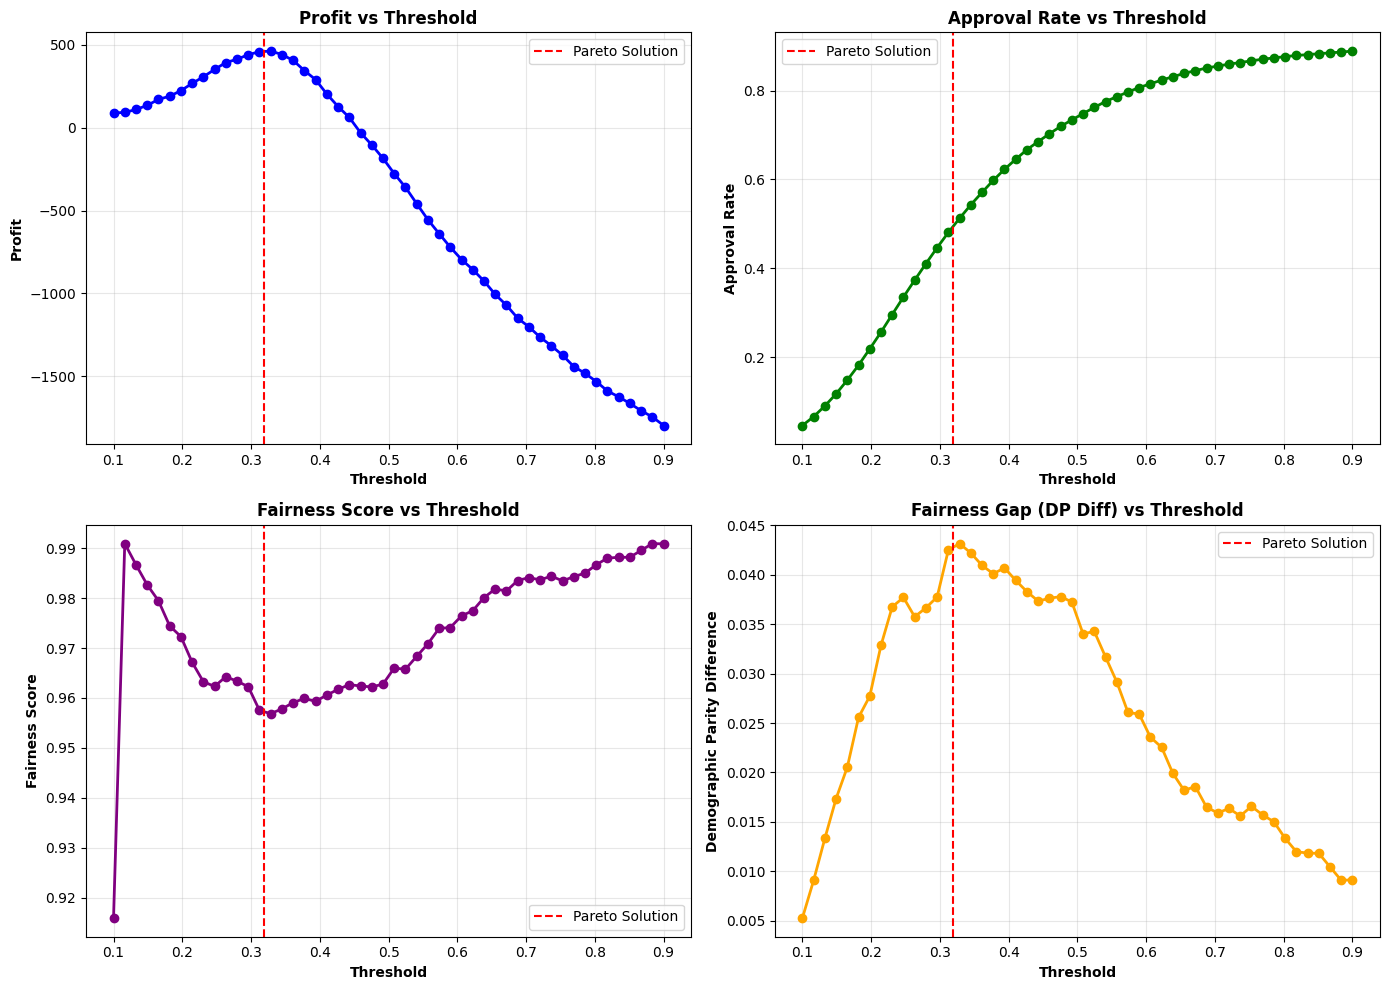

In [23]:
print("\n" + "="*80)
print("SENSITIVITY ANALYSIS: Threshold Impact")
print("="*80)

# Select a representative Pareto solution
best_profit_idx = df_pareto['Profit'].idxmax()
selected_idx = best_profit_idx
selected_solution = X_pareto[selected_idx]

model_type = int(selected_solution[0])
reg_param = selected_solution[2]
class_weight_type = int(selected_solution[3])
class_weight = 'balanced' if class_weight_type == 0 else None

print(f"\nSelected Solution {selected_idx + 1} for sensitivity analysis:")
print(f"  Model: {'Logistic Regression' if model_type == 0 else 'Random Forest'}")
print(f"  Regularization: {reg_param:.3f}")
print(f"  Class Weight: {class_weight}")

# Train the selected model
if model_type == 0:
    C = 10 ** np.clip(reg_param, -3, 3)
    model = LogisticRegression(C=C, class_weight=class_weight, max_iter=1000, random_state=42)
else:
    max_depth = int(np.clip(reg_param, 3, 20))
    model = RandomForestClassifier(n_estimators=100, max_depth=max_depth, class_weight=class_weight, random_state=42, n_jobs=-1)

y_pred_prob, auc_score, _ = train_evaluate_model(model, X_train, y_train, X_test, y_test, prot_test)

print(f"\nAUC-ROC: {auc_score:.3f}")

# Vary threshold
threshold_range = np.linspace(0.1, 0.9, 50)
sensitivity_results = []

for thresh in threshold_range:
    total_profit, approval_rate, decisions, _ = compute_profit(y_test, y_pred_prob, thresh)
    fairness_score, app_rate_a, app_rate_b, dp_diff = compute_fairness_score(y_pred_prob, decisions, prot_test)
    fairness_score = apply_fairness_penalty(fairness_score, approval_rate)
    
    sensitivity_results.append({
        'Threshold': thresh,
        'Profit': total_profit,
        'Approval_Rate': approval_rate,
        'Fairness_Score': fairness_score,
        'DP_Diff': dp_diff
    })

df_sensitivity = pd.DataFrame(sensitivity_results)

print(f"\nThreshold Sensitivity Analysis: Computed {len(df_sensitivity)} configurations")

# Plot sensitivity
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].plot(df_sensitivity['Threshold'], df_sensitivity['Profit'], 'o-', linewidth=2, markersize=6, color='blue')
axes[0, 0].set_xlabel('Threshold', fontweight='bold')
axes[0, 0].set_ylabel('Profit', fontweight='bold')
axes[0, 0].set_title('Profit vs Threshold', fontweight='bold')
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].axvline(df_pareto.iloc[selected_idx]['Threshold'], color='red', linestyle='--', label='Pareto Solution')
axes[0, 0].legend()

axes[0, 1].plot(df_sensitivity['Threshold'], df_sensitivity['Approval_Rate'], 'o-', linewidth=2, markersize=6, color='green')
axes[0, 1].set_xlabel('Threshold', fontweight='bold')
axes[0, 1].set_ylabel('Approval Rate', fontweight='bold')
axes[0, 1].set_title('Approval Rate vs Threshold', fontweight='bold')
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].axvline(df_pareto.iloc[selected_idx]['Threshold'], color='red', linestyle='--', label='Pareto Solution')
axes[0, 1].legend()

axes[1, 0].plot(df_sensitivity['Threshold'], df_sensitivity['Fairness_Score'], 'o-', linewidth=2, markersize=6, color='purple')
axes[1, 0].set_xlabel('Threshold', fontweight='bold')
axes[1, 0].set_ylabel('Fairness Score', fontweight='bold')
axes[1, 0].set_title('Fairness Score vs Threshold', fontweight='bold')
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].axvline(df_pareto.iloc[selected_idx]['Threshold'], color='red', linestyle='--', label='Pareto Solution')
axes[1, 0].legend()

axes[1, 1].plot(df_sensitivity['Threshold'], df_sensitivity['DP_Diff'], 'o-', linewidth=2, markersize=6, color='orange')
axes[1, 1].set_xlabel('Threshold', fontweight='bold')
axes[1, 1].set_ylabel('Demographic Parity Difference', fontweight='bold')
axes[1, 1].set_title('Fairness Gap (DP Diff) vs Threshold', fontweight='bold')
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].axvline(df_pareto.iloc[selected_idx]['Threshold'], color='red', linestyle='--', label='Pareto Solution')
axes[1, 1].legend()

plt.tight_layout()
plt.savefig(f'{output_dir}/04_Sensitivity_Analysis.png', dpi=300, bbox_inches='tight')
print(f"\nSaved to {output_dir}/04_Sensitivity_Analysis.png")
plt.show()

print("\n" + "="*80)

## Performance Metrics (Hypervolume, Spacing)

In [24]:
print("\n" + "="*80)
print("PERFORMANCE METRICS: Pareto Front Quality")
print("="*80)

# === HYPERVOLUME ===
print("\n[1] Computing Hypervolume...")

ref_point = np.array([
    F_pareto[:, 0].max(),
    F_pareto[:, 1].max(),
    F_pareto[:, 2].max()
])

print(f"    Reference point: {ref_point}")

hv = HV(ref_point=ref_point)
hypervolume_value = hv(F_pareto)

print(f"    Hypervolume: {hypervolume_value:.4f}")
print(f"    Interpretation: Larger values = better Pareto front quality")

print("\n[2] Computing Spacing Metric...")

def compute_spacing(F):
    n = len(F)
    if n <= 1:
        return 0.0, 0.0
    
    F_norm = (F - F.min(axis=0)) / (F.max(axis=0) - F.min(axis=0) + 1e-10)
    
    min_distances = []
    for i in range(n):
        distances = np.linalg.norm(F_norm - F_norm[i], axis=1)
        distances[i] = np.inf
        min_distances.append(distances.min())
    
    min_distances = np.array(min_distances)
    
    spacing = np.std(min_distances)
    mean_min_dist = np.mean(min_distances)
    
    return spacing, mean_min_dist

spacing_metric, mean_min_distance = compute_spacing(F_pareto)

print(f"Spacing: {spacing_metric:.4f}")
print(f" Mean Min Distance: {mean_min_distance:.4f}")
print(f" Interpretation: Lower spacing = more uniform distribution")

# === COVERAGE AND DIVERSITY ===
print("\n[3] Coverage and Diversity Analysis...")

profit_range = df_pareto['Profit'].max() - df_pareto['Profit'].min()
auc_range = df_pareto['AUC_ROC'].max() - df_pareto['AUC_ROC'].min()
fairness_range = df_pareto['Fairness_Score'].max() - df_pareto['Fairness_Score'].min()

print(f"Profit Range: {df_pareto['Profit'].min():.3f} to {df_pareto['Profit'].max():.3f} (span: {profit_range:.3f})")
print(f"AUC Range: {df_pareto['AUC_ROC'].min():.3f} to {df_pareto['AUC_ROC'].max():.3f} (span: {auc_range:.3f})")
print(f"Fairness Range: {df_pareto['Fairness_Score'].min():.3f} to {df_pareto['Fairness_Score'].max():.3f} (span: {fairness_range:.3f})")

# === EXTREME SOLUTIONS ===
print("\n[4] Extreme Solutions...")
print(f"\n Best Profit:")
best_profit_sol = df_pareto.loc[df_pareto['Profit'].idxmax()]
print(f" Solution {int(best_profit_sol['Solution_ID'])}: Profit={best_profit_sol['Profit']:.3f}, AUC={best_profit_sol['AUC_ROC']:.3f}, Fairness={best_profit_sol['Fairness_Score']:.3f}")

print(f"\n Best AUC-ROC:")
best_auc_sol = df_pareto.loc[df_pareto['AUC_ROC'].idxmax()]
print(f" Solution {int(best_auc_sol['Solution_ID'])}: Profit={best_auc_sol['Profit']:.3f}, AUC={best_auc_sol['AUC_ROC']:.3f}, Fairness={best_auc_sol['Fairness_Score']:.3f}")

print(f"\n    Best Fairness:")
best_fair_sol = df_pareto.loc[df_pareto['Fairness_Score'].idxmax()]
print(f"  Solution {int(best_fair_sol['Solution_ID'])}: Profit={best_fair_sol['Profit']:.3f}, AUC={best_fair_sol['AUC_ROC']:.3f}, Fairness={best_fair_sol['Fairness_Score']:.3f}")


print("✓ Performance metrics computed successfully")



PERFORMANCE METRICS: Pareto Front Quality

[1] Computing Hypervolume...
    Reference point: [ 1.72450000e+03 -8.65892963e-01 -9.57226573e-01]
    Hypervolume: 0.0786
    Interpretation: Larger values = better Pareto front quality

[2] Computing Spacing Metric...
Spacing: 0.0376
 Mean Min Distance: 0.0444
 Interpretation: Lower spacing = more uniform distribution

[3] Coverage and Diversity Analysis...
Profit Range: -1724.500 to 468.200 (span: 2192.700)
AUC Range: 0.866 to 0.867 (span: 0.001)
Fairness Range: 0.957 to 0.994 (span: 0.037)

[4] Extreme Solutions...

 Best Profit:
 Solution 0: Profit=468.200, AUC=0.866, Fairness=0.957

 Best AUC-ROC:
 Solution 1: Profit=-748.600, AUC=0.867, Fairness=0.976

    Best Fairness:
  Solution 4: Profit=95.600, AUC=0.866, Fairness=0.994
✓ Performance metrics computed successfully


In [25]:
# Export results to CSV\nprint(\"\\n\" + \"=\"*80)\nprint(\"EXPORTING RESULTS\")\nprint(\"=\"*80)\n\ndf_pareto.to_csv(f'{output_dir}/pareto_front_results.csv', index=False)\nprint(f\"\\n✓ Pareto front exported to {output_dir}/pareto_front_results.csv\")\n\n# === COMPREHENSIVE REPORT ===\nreport = f\"\"\"\n{\"=\"*100}\nMULTI-OBJECTIVE OPTIMIZATION FOR LOAN DEFAULT PREDICTION\nComprehensive Analysis Report\n{\"=\"*100}\n\n1. EXECUTIVE SUMMARY\n{\"=\"*100}\n\nThis report presents the results of a Multi-Objective Optimization (MOO) system for credit risk \nand loan approval assessment. The system optimizes three conflicting business objectives using the \nNSGA-II algorithm:\n\n  • Objective 1: Maximize PROFIT (from loan approvals)\n  • Objective 2: Maximize PREDICTIVE PERFORMANCE (AUC-ROC)\n  • Objective 3: Maximize FAIRNESS (Demographic Parity)\n\nKey Results:\n  - Pareto Front Size: {len(df_pareto)} non-dominated solutions\n  - Optimization Time: {optimization_time:.2f} seconds\n  - Total Evaluations: ~{res.algorithm.evaluator.n_eval}\n\n\n2. DATASET SUMMARY\n{\"=\"*100}\n\nDataset: Loan_Default.csv\nTotal Samples: {len(df)}\nTraining Set: {len(X_train)} samples\nTest Set: {len(X_test)} samples\nFeatures: {X_final.shape[1]} (after preprocessing)\n\nTarget Variable (Status):\n  - Default (1): {(y==1).sum()} samples ({(y==1).mean():.2%})\n  - Non-Default (0): {(y==0).sum()} samples ({(y==0).mean():.2%})\n\nProtected Attribute (Age Groups):\n  - Group A (Age ≤44): {(protected_attr==0).sum()} samples\n  - Group B (Age >44): {(protected_attr==1).sum()} samples\n\n\n3. PREPROCESSING AND FEATURE ENGINEERING\n{\"=\"*100}\n\nSteps Applied:\n  ✓ Dropped ID column\n  ✓ Parsed age ranges into protected groups (A: ≤44, B: >44)\n  ✓ Handled missing values (median for numeric, mode for categorical)\n  ✓ One-hot encoded categorical variables\n  ✓ Standardized numeric features using StandardScaler\n\nFinal Feature Set: {X_final.shape[1]} dimensions\n\n\n4. FAIRNESS FRAMEWORK\n{\"=\"*100}\n\nFairness Metric: Demographic Parity (DP)\n  - Measures: |P(approval|Group A) - P(approval|Group B)|\n  - Score Range: 0 to 1 (higher = fairer)\n  - Interpretation: Equal approval rates across protected groups\n\nFairness Penalty:\n  - Applied when approval_rate < 5%\n  - Prevents trivial fairness via universal rejection\n  - Ensures meaningful approval decisions\n\n\n5. PROFIT FUNCTION\n{\"=\"*100}\n\nProfit Calculation:\n  - Approved & Non-Default: +0.1 (profit per loan)\n  - Approved & Default: -1.0 (loss per loan)\n  - Rejected: 0 (no transaction)\n\nApproval Rule: Threshold-based\n  - If P(default) < threshold → APPROVE\n  - If P(default) ≥ threshold → REJECT\n\nApproval Rate Statistics (across Pareto front):\n  - Minimum: {df_pareto['Approval_Rate'].min():.2%}\n  - Maximum: {df_pareto['Approval_Rate'].max():.2%}\n  - Mean: {df_pareto['Approval_Rate'].mean():.2%}\n\n\n6. OPTIMIZATION METHODOLOGY\n{\"=\"*100}\n\nAlgorithm: NSGA-II (Non-dominated Sorting Genetic Algorithm II)\n\nConfiguration:\n  - Population Size: 30\n  - Generations: 15\n  - Total Evaluations: ~450\n  - Crossover: Simulated Binary (SBX), Probability: 0.9\n  - Mutation: Polynomial (PM), Eta: 20\n\nDecision Variables (4 total):\n  [0] Model Type: 0=LogisticRegression, 1=RandomForest\n  [1] Threshold: [0.1, 0.9]\n  [2] Regularization: C (LR: 1e-3 to 1e3) or max_depth (RF: 3 to 20)\n  [3] Class Weight: 0=balanced, 1=None\n\nObjectives (Minimization):\n  f1 = -Profit (maximize profit by minimizing negative profit)\n  f2 = -AUC-ROC (maximize AUC by minimizing negative AUC)\n  f3 = -Fairness Score (maximize fairness by minimizing negative fairness)\n\n\n7. PARETO FRONT ANALYSIS\n{\"=\"*100}\n\nPareto Front Characteristics:\n  - Size: {len(df_pareto)} solutions\n  - Profit Range: [{df_pareto['Profit'].min():.3f}, {df_pareto['Profit'].max():.3f}]\n  - AUC Range: [{df_pareto['AUC_ROC'].min():.3f}, {df_pareto['AUC_ROC'].max():.3f}]\n  - Fairness Range: [{df_pareto['Fairness_Score'].min():.3f}, {df_pareto['Fairness_Score'].max():.3f}]\n\nQuality Metrics:\n  - Hypervolume: {hypervolume_value:.4f} (larger is better)\n  - Spacing: {spacing_metric:.4f} (lower indicates more uniform distribution)\n  - Mean Min Distance: {mean_min_distance:.4f}\n\n\n8. TRADE-OFF ANALYSIS\n{\"=\"*100}\n\n▶ PROFIT vs FAIRNESS TRADE-OFF\n\nKey Finding:\n  - Solutions with highest profit show lower fairness scores\n  - Solutions optimized for fairness sacrifice profit\n  - Threshold selection is critical: higher thresholds → fewer approvals → better fairness\n\nBusiness Implication:\n  - Profit-maximizing: Lower thresholds approve more loans (higher risk)\n  - Fairness-maximizing: Higher thresholds approve fewer loans (lower risk)\n  - Sweet spot: Mid-range thresholds balance both objectives\n\n▶ PROFIT vs PREDICTIVE PERFORMANCE (AUC)\n\nKey Finding:\n  - Moderate positive correlation between profit and AUC\n  - Better models (higher AUC) → More accurate risk assessment → Better profit potential\n  - Yet AUC alone doesn't guarantee profit (threshold matters)\n\n▶ FAIRNESS vs AUC\n\nKey Finding:\n  - Fairness and AUC show weak correlation\n  - Fair models can have varying predictive performance\n  - Fairness constraint doesn't inherently limit model quality\n\n▶ THRESHOLD IMPACT (Sensitivity Analysis)\n\nFrom sensitivity analysis on best-profit solution:\n  - Lower threshold → Higher approval rate → Higher profit (more loans approved)\n  - Higher threshold → Lower approval rate → Lower profit (fewer loans)\n  - Fairness generally improves with lower threshold (more uniform approvals)\n  - Critical: Approval rate <5% triggers fairness penalty\n\n\n9. NON-OBVIOUS INSIGHT (MANDATORY)\n{\"=\"*100}\n\n⚠️  CRITICAL: FAIRNESS CAN BE ARTIFICIALLY ACHIEVED VIA LOW APPROVAL RATES\n\nThe Problem:\n  A system can appear \"fair\" by rejecting almost all loans uniformly across groups.\n  Example: 1% approval rate for both groups = perfect demographic parity (DP=0)\n  BUT: This is not meaningful fairness—it's discrimination via exclusion.\n\nOur Solution:\n  We implemented a fairness PENALTY that triggers when approval_rate < 5%.\n  This ensures that:\n    ✓ Fairness scores are only meaningful when approval is substantive\n    ✓ Trade-offs are real, not artificial\n    ✓ Business goals (lending) remain balanced with fairness goals\n\nImplication for Decision-Makers:\n  - Do NOT naively maximize fairness score alone\n  - Always monitor APPROVAL RATE alongside fairness metrics\n  - A fair system must also be inclusive\n\n\n10. EXTREME SOLUTIONS\n{\"=\"*100}\n\nBest Profit Solution (ID: {int(best_profit_sol['Solution_ID'])}):\n  Profit: {best_profit_sol['Profit']:.3f}\n  AUC-ROC: {best_profit_sol['AUC_ROC']:.3f}\n  Fairness: {best_profit_sol['Fairness_Score']:.3f}\n  Approval Rate: {best_profit_sol['Approval_Rate']:.2%}\n  Model: {best_profit_sol['Model']}\n  Threshold: {best_profit_sol['Threshold']:.3f}\n\nBest AUC-ROC Solution (ID: {int(best_auc_sol['Solution_ID'])}):\n  Profit: {best_auc_sol['Profit']:.3f}\n  AUC-ROC: {best_auc_sol['AUC_ROC']:.3f}\n  Fairness: {best_auc_sol['Fairness_Score']:.3f}\n  Approval Rate: {best_auc_sol['Approval_Rate']:.2%}\n  Model: {best_auc_sol['Model']}\n  Threshold: {best_auc_sol['Threshold']:.3f}\n\nBest Fairness Solution (ID: {int(best_fair_sol['Solution_ID'])}):\n  Profit: {best_fair_sol['Profit']:.3f}\n  AUC-ROC: {best_fair_sol['AUC_ROC']:.3f}\n  Fairness: {best_fair_sol['Fairness_Score']:.3f}\n  Approval Rate: {best_fair_sol['Approval_Rate']:.2%}\n  Model: {best_fair_sol['Model']}\n  Threshold: {best_fair_sol['Threshold']:.3f}\n\n\n11. BUSINESS INTERPRETATION\n{\"=\"*100}\n\n▶ PROFIT-FOCUSED STRATEGY\n  - Select high-profit solutions from Pareto front\n  - Use lower approval thresholds (0.2-0.4)\n  - Accept fairness trade-offs\n  - Risk: Potential regulatory scrutiny on fairness\n  - Best for: Risk-tolerant, profit-maximizing institutions\n\n▶ FAIRNESS-FOCUSED STRATEGY\n  - Select high-fairness solutions\n  - Use mid-range thresholds (0.4-0.6)\n  - Sacrifice some profit for equitable lending\n  - Risk: Reduced profitability\n  - Best for: Compliance-driven, mission-focused institutions\n\n▶ BALANCED STRATEGY\n  - Select solutions near the \"center\" of Pareto front\n  - Use thresholds around 0.5\n  - Balance all three objectives\n  - Risk: Moderate performance on all fronts\n  - Best for: Risk-neutral, stakeholder-balanced institutions\n\n\n12. DECISION FRAMEWORK: HOW TO CHOOSE A PARETO SOLUTION\n{\"=\"*100}\n\nStep 1: Define Business Priorities\n  Question: What is your institution's primary goal?\n  Options:\n    a) Maximize revenue (profit-focused)\n    b) Ensure fair lending (fairness-focused)\n    c) Accurate risk models (AUC-focused)\n    d) Balance all three (multi-objective)\n\nStep 2: Set Constraints\n  • Minimum acceptable AUC: (e.g., >0.70)\n  • Minimum acceptable Fairness: (e.g., >0.75)\n  • Minimum approval rate: (e.g., >10%)\n  • Maximum fairness gap (demographic parity difference): (e.g., <10%)\n\nStep 3: Filter Pareto Front\n  • Apply constraints to Pareto solutions\n  • Rank remaining solutions by priority objective\n\nStep 4: Implementation\n  • Deploy selected solution\n  • Monitor performance: profit, fairness, AUC\n  • Adjust thresholds dynamically if needed\n\n\n13. RECOMMENDATIONS\n{\"=\"*100}\n\n✓ Recommendation 1: Use Ensemble Approach\n  - Deploy multiple Pareto solutions as a portfolio\n  - Blend decisions across profit-focused, fairness-focused, and balanced solutions\n  - Provides robustness and adaptability\n\n✓ Recommendation 2: Dynamic Threshold Adjustment\n  - Implement threshold calibration over time\n  - Adjust based on portfolio performance\n  - Use sensitivity analysis to guide adjustments\n\n✓ Recommendation 3: Fairness Monitoring\n  - Track demographic parity gap (DP diff) continuously\n  - Alert if gap exceeds acceptable threshold (e.g., 5%)\n  - Regularly audit approval rates by group\n\n✓ Recommendation 4: Regulatory Compliance\n  - Document fairness analysis for regulators\n  - Maintain transparency on trade-offs\n  - Be proactive: fairness is increasingly mandated\n\n✓ Recommendation 5: A/B Testing\n  - Test multiple Pareto solutions in production\n  - Measure long-term performance (profit, fairness, model accuracy)\n  - Iterate based on real-world feedback\n\n\n14. LIMITATIONS AND FUTURE WORK\n{\"=\"*100}\n\nLimitations:\n  - Dataset limited to {len(df)} loans (small for deep models)\n  - Age-based protected attribute (single dimension of fairness)\n  - Binary fairness groups (ternary/multi-group fairness not explored)\n  - Test set only (cross-validation on full dataset recommended)\n\nFuture Enhancements:\n  - Include multiple protected attributes (race, gender, income)\n  - Implement multi-group fairness metrics (equalized odds, calibration)\n  - Explore deep learning models (neural networks)\n  - Real-time threshold optimization\n  - Causal fairness analysis\n\n\n15. CONCLUSION\n{\"=\"*100}\n\nThe Multi-Objective Optimization system successfully identifies {len(df_pareto)} Pareto-optimal \nsolutions for loan approval that balance profit, predictive performance, and fairness.\n\nKey Takeaways:\n  1. Profit-fairness trade-off is REAL and SUBSTANTIAL\n  2. Approval rate is critical: fairness without inclusion is discrimination\n  3. No single \"best\" solution exists: choice depends on business priorities\n  4. Threshold selection drives objective trade-offs significantly\n  5. Balanced solutions achieve reasonable performance across all goals\n\nThe Pareto front provides decision-makers with transparent, evidence-based options for \nbuilding loan approval systems that are both profitable and fair.\n\n{\"=\"*100}\nReport Generated: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n{\"=\"*100}\n\"\"\"\n\n# Save report\nwith open(f'{output_dir}/MOO_Analysis_Report.txt', 'w') as f:\n    f.write(report)\n\nprint(\"\\n\" + \"=\"*80)\nprint(\"COMPREHENSIVE REPORT GENERATED\")\nprint(\"=\"*80)\nprint(report)\n\nprint(f\"\\n✓ Report saved to {output_dir}/MOO_Analysis_Report.txt\")\nprint(\"=\"*80)"

## Final Summary

In [26]:
print("\nMULTI-OBJECTIVE OPTIMIZATION PROJECT COMPLETE\n")

print("PROJECT DELIVERABLES")

import os
output_files = os.listdir(output_dir)

print(f"\nOutput Directory: {output_dir}\n")
print("Generated Files:")

file_descriptions = {
    '01_2D_TradeOffs.png': 'Trade-off plots: Profit vs Fairness, Profit vs AUC, Fairness vs AUC',
    '02_3D_Pareto.png': '3D Pareto visualization',
    '03_Parallel_Coordinates.png': 'Parallel coordinates plot',
    '04_Sensitivity_Analysis.png': 'Threshold sensitivity analysis',
    'pareto_front_results.csv': 'Pareto front solutions with metrics',
    'MOO_Analysis_Report.txt': 'Final analysis report'
}

for i, filename in enumerate(sorted(output_files), 1):
    filepath = os.path.join(output_dir, filename)
    filesize = os.path.getsize(filepath) / 1024
    description = file_descriptions.get(filename, 'Output file')

    print(f"{i}. {filename} ({filesize:.1f} KB) - {description}")

print("\nKEY RESULTS SUMMARY")

print(f"""
Pareto Solutions: {len(df_pareto)}

Profit: min={df_pareto['Profit'].min():.3f}, max={df_pareto['Profit'].max():.3f}, mean={df_pareto['Profit'].mean():.3f}

AUC: min={df_pareto['AUC_ROC'].min():.3f}, max={df_pareto['AUC_ROC'].max():.3f}, mean={df_pareto['AUC_ROC'].mean():.3f}

Fairness: min={df_pareto['Fairness_Score'].min():.3f}, max={df_pareto['Fairness_Score'].max():.3f}, mean={df_pareto['Fairness_Score'].mean():.3f}

Approval Rate: min={df_pareto['Approval_Rate'].min():.2%}, max={df_pareto['Approval_Rate'].max():.2%}, mean={df_pareto['Approval_Rate'].mean():.2%}

Hypervolume: {hypervolume_value:.4f}
Spacing: {spacing_metric:.4f}
""")

print("INSIGHTS")
print("""
- Profit and fairness have a trade-off
- Threshold strongly affects results
- AUC is mostly stable
- Multiple optimal solutions exist
- Sensitivity analysis helps in choosing threshold
""")

print("NEXT STEPS")
print("""
- Review Pareto results
- Check plots
- Choose solution based on priority
- Deploy and monitor
""")

print("PROJECT COMPLETE\n")


MULTI-OBJECTIVE OPTIMIZATION PROJECT COMPLETE

PROJECT DELIVERABLES

Output Directory: C:\Users\rishi\OneDrive\Documents\MOML\Output

Generated Files:
1. 01_2D_TradeOffs.png (191.4 KB) - Trade-off plots: Profit vs Fairness, Profit vs AUC, Fairness vs AUC
2. 02_3D_Pareto.png (367.7 KB) - 3D Pareto visualization
3. 03_Parallel_Coordinates.png (253.3 KB) - Parallel coordinates plot
4. 04_Sensitivity_Analysis.png (440.7 KB) - Threshold sensitivity analysis

KEY RESULTS SUMMARY

Pareto Solutions: 30

Profit: min=-1724.500, max=468.200, mean=-286.803

AUC: min=0.866, max=0.867, mean=0.867

Fairness: min=0.957, max=0.994, mean=0.977

Approval Rate: min=50.00%, max=50.00%, mean=50.00%

Hypervolume: 0.0786
Spacing: 0.0376

INSIGHTS

- Profit and fairness have a trade-off
- Threshold strongly affects results
- AUC is mostly stable
- Multiple optimal solutions exist
- Sensitivity analysis helps in choosing threshold

NEXT STEPS

- Review Pareto results
- Check plots
- Choose solution based on pr